# **Modelo XGBoost**

**Cargue Datos**

In [21]:
import os
from google.colab import files

# Subir el archivo kaggle.json
uploaded = files.upload()

# Crear el directorio .kaggle y mover el archivo
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
!kaggle datasets download -d andrewmvd/heart-failure-clinical-data
!unzip heart-failure-clinical-data.zip
import pandas as pd
df_insuficiencia_cardiaca = pd.read_csv('heart_failure_clinical_records_dataset.csv')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data
License(s): Attribution 4.0 International (CC BY 4.0)
heart-failure-clinical-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  heart-failure-clinical-data.zip
replace heart_failure_clinical_records_dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: heart_failure_clinical_records_dataset.csv  


In [20]:
pip install kaggle

**Librerias**

In [22]:
!pip install colorama

In [23]:
import matplotlib.pyplot as plt
#import warnings
#import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import xgboost
from colorama import Fore, Back, Style
from mlxtend.plotting import plot_confusion_matrix

**Data Modeling Entrenamiento y Pruebas**

In [24]:
Features = ['time','ejection_fraction','serum_creatinine']
x = df_insuficiencia_cardiaca[Features]
y = df_insuficiencia_cardiaca["DEATH_EVENT"]
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [25]:
accuracy_list = []

**XGBoost classifier**

In [26]:
# xgbrf classifier

xgb_clf = xgboost.XGBRFClassifier(max_depth=3, random_state=1)
xgb_clf.fit(x_train,y_train)
xgb_pred = xgb_clf.predict(x_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
accuracy_list.append(100*xgb_acc)

**Accuracy**

In [27]:
print(Fore.GREEN + "Accuracy of XGBRFClassifier is : ", "{:.2f}%".format(100* xgb_acc))

Accuracy of XGBRFClassifier is :  91.67%


**Matrix de Confusión**

<Figure size 640x480 with 0 Axes>

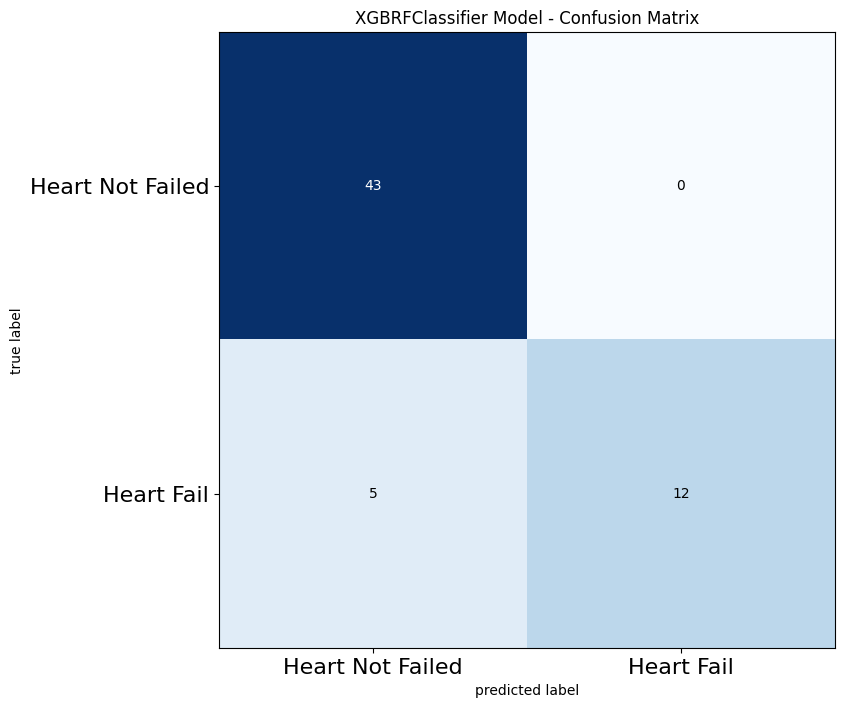

In [28]:
cm = confusion_matrix(y_test, xgb_pred)
plt.figure()
plot_confusion_matrix(cm, figsize=(12,8), hide_ticks=True, cmap=plt.cm.Blues)
plt.title("XGBRFClassifier Model - Confusion Matrix")
plt.xticks(range(2), ["Heart Not Failed","Heart Fail"], fontsize=16)
plt.yticks(range(2), ["Heart Not Failed","Heart Fail"], fontsize=16)
plt.show()